In [3]:
!pip install   graphviz

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
import graphviz
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score


In [38]:
df=pd.read_csv("iris_dataset.csv")

In [40]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [44]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [46]:
X = df.drop("target", axis=1)
y = LabelEncoder().fit_transform(df["target"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### TRAIN DECISION TREE

In [60]:
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))


Decision Tree Accuracy: 1.0


### Control Tree Depth to Avoid Overfitting

In [66]:
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))


Random Forest Accuracy: 1.0


### Train Random Forest Classifier

In [70]:

rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))


Random Forest Accuracy: 1.0


### Feature Importance (Random Forest)

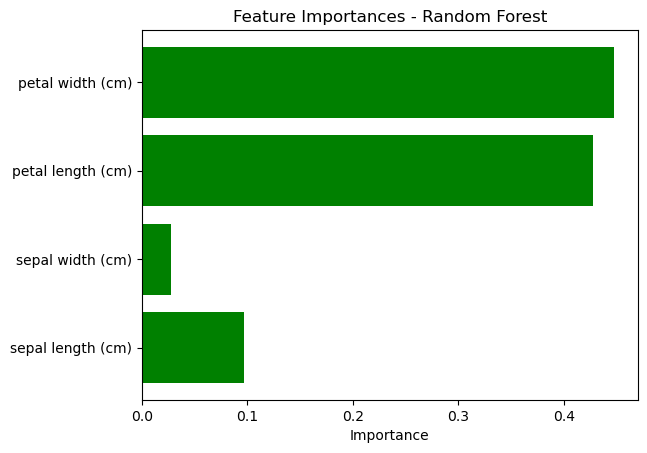

In [79]:
importances = rf.feature_importances_
plt.barh(X.columns, importances, color= 'green')
plt.xlabel("Importance")
plt.title("Feature Importances - Random Forest")
plt.show()

###  Cross-Validation Scores

In [82]:
dt_cv = cross_val_score(dt_pruned, X, y, cv=5)
rf_cv = cross_val_score(rf, X, y, cv=5)

print("Cross-Val Accuracy (Decision Tree):", dt_cv.mean())
print("Cross-Val Accuracy (Random Forest):", rf_cv.mean())

Cross-Val Accuracy (Decision Tree): 0.96
Cross-Val Accuracy (Random Forest): 0.9666666666666668
